# ML Clásico con XGBoost — Titanic
**Objetivo:** Entender el flujo completo de entrenamiento — desde los datos hasta la evaluación final.

**Hilo de la sesión:**
1. Exploración rápida de los datos
2. Preprocesamiento mínimo (incluyendo descarte de features irrelevantes)
3. Split train / val / test
4. Entrenamiento
5. Métricas calculadas a mano (sin sklearn)
6. Overfitting en vivo
7. Evaluación final honesta en test

**Recuerda el ciclo universal:** Datos → Modelo → Predicción → Error → Ajuste → repetir

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import xgboost as xgb

SEED = 42
np.random.seed(SEED)
print("Todo importado correctamente ✓")

Todo importado correctamente ✓


---
## 1. Carga de datos

Los datos están en un archivo CSV. Lo cargamos con `pd.read_csv`.


In [2]:
# Cargamos los datos desde CSV
df = pd.read_csv('titanic.csv')
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Shape: (390, 10)
Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'ticket_length', 'name_length']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,ticket_length,name_length
0,0,3,male,22.0,1,0,7.2500,S,6,23
1,1,1,female,38.0,1,0,71.2833,C,6,51
2,1,3,female,26.0,0,0,7.9250,S,6,22
3,1,1,female,35.0,1,0,53.1000,S,5,44
4,0,3,male,35.0,0,0,8.0500,S,6,24


In [3]:
# Tipos y nulos de un vistazo
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   survived       390 non-null    int64  
 1   pclass         390 non-null    int64  
 2   sex            390 non-null    str    
 3   age            288 non-null    float64
 4   sibsp          390 non-null    int64  
 5   parch          390 non-null    int64  
 6   fare           390 non-null    float64
 7   embarked       390 non-null    str    
 8   ticket_length  390 non-null    int64  
 9   name_length    390 non-null    int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 30.6 KB


In [4]:
# ¿Está el target balanceado?
# Crítico: si hay muchos más 0 que 1, accuracy sola no sirve
print("Distribución del target:")
print(df['survived'].value_counts())
print(f"\nProporción de supervivientes: {df['survived'].mean():.1%}")

Distribución del target:
survived
0    304
1     86
Name: count, dtype: int64

Proporción de supervivientes: 22.1%


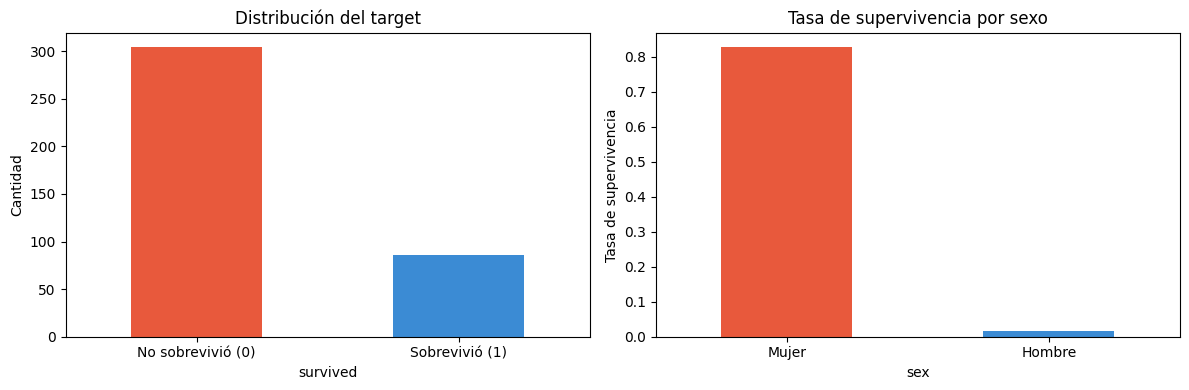


💡 El sexo ya nos dice mucho. Las features NO son independientes entre sí.


In [ ]:
# Visualización rápida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#E8593C', '#3B8BD4'])
axes[0].set_title('Distribución del target')
axes[0].set_xticklabels(['No sobrevivió (0)', 'Sobrevivió (1)'], rotation=0)
axes[0].set_ylabel('Cantidad')

df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[1], color=['#E8593C', '#3B8BD4'])
axes[1].set_title('Tasa de supervivencia por sexo')
axes[1].set_xticklabels(['Mujer', 'Hombre'], rotation=0)
axes[1].set_ylabel('Tasa de supervivencia')

plt.tight_layout()
plt.show()
print()
print("  El sexo ya nos dice mucho. Las features NO son independientes entre sí.")

---
## 2. Preprocesamiento mínimo

Los modelos de ML solo entienden números. Hay que:
1. **Descartar features irrelevantes** — `ticket_length` y `name_length` no aportan información real sobre la supervivencia
2. Tratar los valores nulos
3. Convertir categorías a números



In [6]:
# Features que vamos a usar — descartamos ticket_length y name_length
FEATURES = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
TARGET   = 'survived'

data = df[FEATURES + [TARGET]].copy()

print("Features descartadas: ticket_length, name_length")
print(f"Features finales: {FEATURES}")
print(f"Shape tras selección: {data.shape}")

Features descartadas: ticket_length, name_length
Features finales: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Shape tras selección: (390, 8)


In [7]:
# Rellenamos nulos — mediana para numéricos, moda para categóricos
# ¿Por qué mediana y no media? Porque la mediana es robusta a outliers
data['age']      = data['age'].fillna(data['age'].median())
data['fare']     = data['fare'].fillna(data['fare'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

print("Nulos restantes:")
print(data.isnull().sum())

Nulos restantes:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [8]:
# Encoding: convertimos categorías a números
le = LabelEncoder()
data['sex']      = le.fit_transform(data['sex'])       # female=0, male=1
data['embarked'] = le.fit_transform(data['embarked'])  # C=0, Q=1, S=2

print("Tipos tras encoding:")
print(data.dtypes)

Tipos tras encoding:
pclass        int64
sex           int64
age         float64
sibsp         int64
parch         int64
fare        float64
embarked      int64
survived      int64
dtype: object


---
## 3. Split train / val / test

- **Train:** el modelo aprende aquí
- **Validation:** usamos para tomar decisiones (hiperparámetros, early stopping)
- **Test:** se abre UNA SOLA VEZ al final — el examen real


In [ ]:
X = data.drop(TARGET, axis=1)
y = data[TARGET]

# Primer split: separamos el 20% como test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Segundo split: del resto, 20% como validación
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

print(f"Train:      {len(X_train)} filas ({len(X_train)/len(X):.0%})")
print(f"Validation: {len(X_val)} filas ({len(X_val)/len(X):.0%})")
print(f"Test:       {len(X_test)} filas ({len(X_test)/len(X):.0%})")
print()
print("  stratify=y garantiza que la proporción de supervivientes")
print("   sea igual en los tres conjuntos.")

Train:      249 filas (64%)
Validation: 63 filas (16%)
Test:       78 filas (20%)

💡 stratify=y garantiza que la proporción de supervivientes
   sea igual en los tres conjuntos.


---
## 4. Entrenamiento

Entrenamos XGBoost con parámetros por defecto.

## Hiperparámetros de XGBoost

Los que **usamos** en este notebook:

| Hiperparámetro | Qué controla |
|---|---|
| `n_estimators` | Número de árboles. Más árboles = más capacidad, más riesgo de overfit |
| `learning_rate` | Cuánto corrige cada árbol los errores del anterior. Valores típicos: 0.01–0.3 |
| `early_stopping_rounds` | Para el entrenamiento si val loss no mejora en N rounds consecutivos |
| `eval_metric` | Métrica que monitoriza durante el entrenamiento (`logloss`, `auc`...) |
| `random_state` | Semilla para reproducibilidad |

Los que **no usamos** pero existen:

| Hiperparámetro | Qué controla |
|---|---|
| `max_depth` | Profundidad máxima de cada árbol (default=6). Más profundo = más complejo |
| `min_child_weight` | Mínimo de muestras en una hoja. Más alto = modelo más conservador |
| `subsample` | Fracción de datos usada por árbol (0.5–1.0). Reduce overfitting |
| `colsample_bytree` | Fracción de features usada por árbol. Como subsample pero para features |
| `gamma` | Ganancia mínima para hacer una nueva división. Actúa como regularización |
| `reg_alpha` | Regularización L1 (Lasso). Penaliza pesos grandes |
| `reg_lambda` | Regularización L2 (Ridge). Penaliza pesos grandes de otra forma |
| `scale_pos_weight` | Útil con clases desbalanceadas. Pondera la clase minoritaria |


## ¿Qué es logloss?

Logloss es la métrica que XGBoost usa internamente durante el entrenamiento para medir cuánto se equivoca.

A diferencia de accuracy, que solo mira si acertó o no, logloss también tiene en cuenta **con qué confianza** predijo el modelo:

- Si predijo "sobrevive" con 99% de probabilidad y era correcto → error casi cero
- Si predijo "sobrevive" con 99% de probabilidad y estaba equivocado → error enorme

**Logloss es el termómetro interno del modelo durante el entrenamiento**. Cuando baja, el modelo está aprendiendo. Cuando en validación deja de bajar y empieza a subir, el modelo ha empezado a memorizar. Eso es exactamente lo que verás en el gráfico siguiente.

In [10]:
model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, y_train)
print("Modelo entrenado ✓")

Modelo entrenado ✓


---
## 5. Métricas calculadas a mano

Vamos a calcular las métricas **sin usar las funciones de sklearn**, implementándolas desde la matriz de confusión. Así repasamos exactamente qué mide cada una.

Recuerda:
- **TP** (Verdadero Positivo): predijo SÍ, era SÍ
- **TN** (Verdadero Negativo): predijo NO, era NO
- **FP** (Falso Positivo): predijo SÍ, era NO
- **FN** (Falso Negativo): predijo NO, era SÍ

In [11]:
DEFAULT_THRESHOLD = 0.5

class ModelMetrics:
    def __init__(self, y_true, y_prob):
        self.y_true = np.array(y_true)
        self.y_prob = np.array(y_prob)

    def calc_precision(self, tp: int, fp: int) -> float:
        return tp / (tp + fp) if (tp + fp) > 0 else 0.0

    def calc_recall(self, tp: int, fn: int) -> float:
        return tp / (tp + fn) if (tp + fn) > 0 else 0.0

    def calc_f1_score(self, prec: float, rec: float) -> float:
        return 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    def calc_accuracy(self, tp: int, fp: int, fn: int, tn: int) -> float:
        total = tp + fp + fn + tn
        return (tp + tn) / total if total > 0 else 0.0

    def calc_false_positive_rate(self, fp: int, tn: int) -> float:
        return 100 * fp / (fp + tn) if (fp + tn) > 0 else 0.0

    def compute_metrics(self, threshold: float = DEFAULT_THRESHOLD):
        y_pred = (self.y_prob >= threshold).astype(int)

        tp = int(((self.y_true == 1) & (y_pred == 1)).sum())
        fp = int(((self.y_true == 0) & (y_pred == 1)).sum())
        fn = int(((self.y_true == 1) & (y_pred == 0)).sum())
        tn = int(((self.y_true == 0) & (y_pred == 0)).sum())

        prec = self.calc_precision(tp, fp)
        rec  = self.calc_recall(tp, fn)
        f1   = self.calc_f1_score(prec, rec)
        acc  = self.calc_accuracy(tp, fp, fn, tn)
        fpr  = self.calc_false_positive_rate(fp, tn)

        metrics = {
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'accuracy':   acc,
            'precision':  prec,
            'recall':     rec,
            'f1':         f1,
            'fpr':        fpr,
        }
        return metrics, np.array(y_pred)

print("Clase ModelMetrics definida ✓")

Clase ModelMetrics definida ✓


In [ ]:
# Calculamos métricas en validación
y_prob_val = model.predict_proba(X_val)[:, 1]
metrics_val = ModelMetrics(y_val, y_prob_val)
results, y_pred_val = metrics_val.compute_metrics()

print("=" * 38)
print("MÉTRICAS EN VALIDACIÓN")
print("=" * 38)
print(f"  TP: {results['TP']}  FP: {results['FP']}")
print(f"  FN: {results['FN']}  TN: {results['TN']}")
print()
print(f"  Accuracy:  {results['accuracy']:.3f}")
print(f"  Precision: {results['precision']:.3f}")
print(f"  Recall:    {results['recall']:.3f}")
print(f"  F1-score:  {results['f1']:.3f}")
print(f"  FPR:       {results['fpr']:.1f}%")
print()
print("Precision: de lo que predijo como 'sobrevivió', ¿cuántos sobrevivieron?")
print(" Recall:    de todos los que sobrevivieron, ¿cuántos encontró el modelo?")

MÉTRICAS EN VALIDACIÓN
  TP: 11  FP: 1
  FN: 3  TN: 48

  Accuracy:  0.937
  Precision: 0.917
  Recall:    0.786
  F1-score:  0.846
  FPR:       2.0%

💡 Precision: de lo que predijo como 'sobrevivió', ¿cuántos sobrevivieron?
   Recall:    de todos los que sobrevivieron, ¿cuántos encontró el modelo?


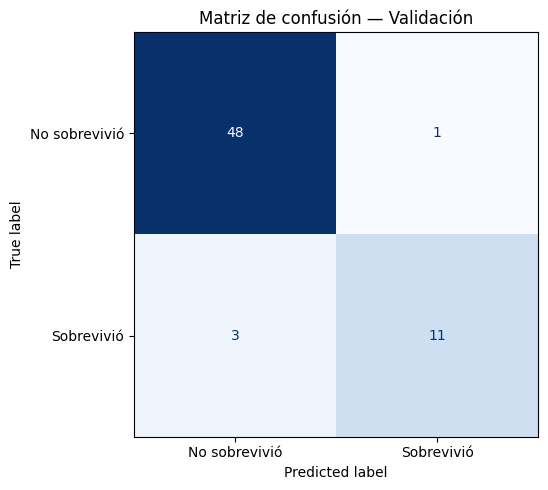


Falsos negativos (predijo 0, era 1): 3 personas
Falsos positivos (predijo 1, era 0): 1 personas


In [13]:
# Matriz de confusión visual
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sobrevivió', 'Sobrevivió'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — Validación')
plt.tight_layout()
plt.show()

print()
print(f"Falsos negativos (predijo 0, era 1): {results['FN']} personas")
print(f"Falsos positivos (predijo 1, era 0): {results['FP']} personas")

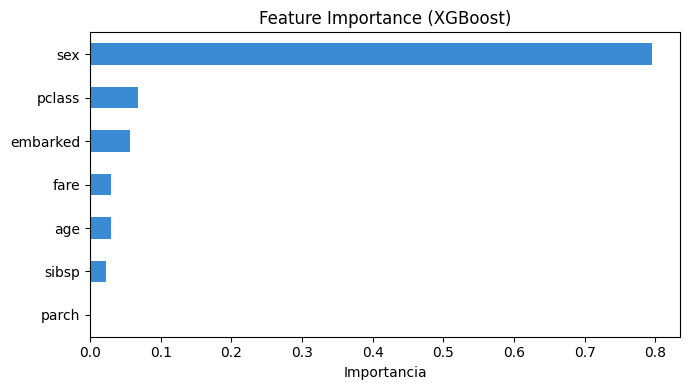

In [14]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='#3B8BD4')
ax.set_title('Feature Importance (XGBoost)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

---
## 6. Overfitting en vivo


In [15]:
model_overfit = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)

model_overfit.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

results_ov = model_overfit.evals_result()
train_loss = results_ov['validation_0']['logloss']
val_loss   = results_ov['validation_1']['logloss']

print(f"Loss mínimo en train: {min(train_loss):.4f} (round {np.argmin(train_loss)})")
print(f"Loss mínimo en val:   {min(val_loss):.4f}  (round {np.argmin(val_loss)})")

Loss mínimo en train: 0.0390 (round 499)
Loss mínimo en val:   0.1149  (round 45)


In [ ]:
checkpoints = {
    'Underfitting (round 5)':   5,
    'Punto óptimo':             np.argmin(val_loss),
    'Overfitting (round 400)':  400,
}

print(f"{'Momento':<30} {'Train Acc':>10} {'Val Acc':>10} {'Val Precision':>14} {'Val Recall':>11}")
print("-" * 80)

for nombre, rnd in checkpoints.items():
    # Reentrenamos con exactamente ese número de árboles
    m_tmp = xgb.XGBClassifier(
        n_estimators=rnd + 1,
        learning_rate=0.1,
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0
    )
    m_tmp.fit(X_train, y_train)

    # Train
    y_prob_tr = m_tmp.predict_proba(X_train)[:, 1]
    m_tr = ModelMetrics(y_train, y_prob_tr)
    r_tr, _ = m_tr.compute_metrics()

    # Val
    y_prob_vl = m_tmp.predict_proba(X_val)[:, 1]
    m_vl = ModelMetrics(y_val, y_prob_vl)
    r_vl, _ = m_vl.compute_metrics()

    print(f"{nombre:<30} {r_tr['accuracy']:>10.3f} {r_vl['accuracy']:>10.3f} "
          f"{r_vl['precision']:>14.3f} {r_vl['recall']:>11.3f}")

print()
print("  Fíjate cómo train accuracy sigue subiendo pero val accuracy se estanca o baja.")
print("   El modelo está memorizando el train set, no aprendiendo a generalizar.")

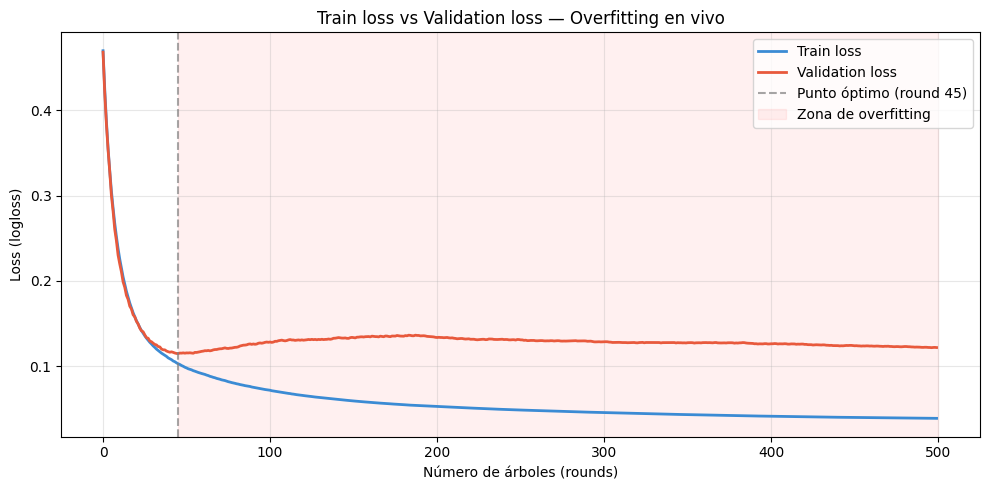


💡 El modelo memoriza el train set pero pierde capacidad de generalizar.


In [ ]:
best_round = np.argmin(val_loss)

fig, ax = plt.subplots(figsize=(10, 5))
rounds = range(len(train_loss))
ax.plot(rounds, train_loss, label='Train loss',      color='#3B8BD4', linewidth=2)
ax.plot(rounds, val_loss,   label='Validation loss', color='#E8593C', linewidth=2)
ax.axvline(x=best_round, color='gray', linestyle='--', alpha=0.7,
           label=f'Punto óptimo (round {best_round})')
ax.axvspan(best_round, len(train_loss), alpha=0.06, color='red', label='Zona de overfitting')
ax.set_xlabel('Número de árboles (rounds)')
ax.set_ylabel('Loss (logloss)')
ax.set_title('Train loss vs Validation loss — Overfitting en vivo')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print()
print("El modelo memoriza el train set pero pierde capacidad de generalizar.")

In [ ]:
checkpoints = {
    'Underfitting (round 5)':   5,
    'Punto óptimo':             np.argmin(val_loss),
    'Overfitting (round 400)':  400,
}

print(f"{'Momento':<30} {'Train Acc':>10} {'Val Acc':>10} {'Val Precision':>14} {'Val Recall':>11}")
print("-" * 80)

for nombre, rnd in checkpoints.items():
    # Reentrenamos con exactamente ese número de árboles
    m_tmp = xgb.XGBClassifier(
        n_estimators=rnd + 1,
        learning_rate=0.1,
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0
    )
    m_tmp.fit(X_train, y_train)

    # Train
    y_prob_tr = m_tmp.predict_proba(X_train)[:, 1]
    m_tr = ModelMetrics(y_train, y_prob_tr)
    r_tr, _ = m_tr.compute_metrics()

    # Val
    y_prob_vl = m_tmp.predict_proba(X_val)[:, 1]
    m_vl = ModelMetrics(y_val, y_prob_vl)
    r_vl, _ = m_vl.compute_metrics()

    print(f"{nombre:<30} {r_tr['accuracy']:>10.3f} {r_vl['accuracy']:>10.3f} "
          f"{r_vl['precision']:>14.3f} {r_vl['recall']:>11.3f}")

print()
print("  Fíjate cómo train accuracy sigue subiendo pero val accuracy se estanca o baja.")
print("   El modelo está memorizando el train set, no aprendiendo a generalizar.")

In [ ]:
# Solución: Early Stopping
model_es = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    random_state=SEED,
    eval_metric='logloss',
    early_stopping_rounds=20,
    verbosity=0
)

model_es.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best round con early stopping: {model_es.best_iteration}")
print(f"Best val loss: {model_es.best_score:.4f}")
print()
print("  Early stopping para cuando la val loss deja de mejorar.")
print("   Lo vamos a usar exactamente igual con RNNs.")

Best round con early stopping: 45
Best val loss: 0.1149

💡 Early stopping para cuando la val loss deja de mejorar.
   Lo vamos a usar exactamente igual con RNNs.


---
## 7. Evaluación final en test

Solo ahora, cuando hemos terminado de tomar todas las decisiones, abrimos el test set.



In [18]:
# Evaluación final con nuestras métricas — solo se hace UNA VEZ
y_prob_test = model_es.predict_proba(X_test)[:, 1]
metrics_test = ModelMetrics(y_test, y_prob_test)
results_test, y_pred_test = metrics_test.compute_metrics()

print("=" * 38)
print("RESULTADO FINAL EN TEST SET")
print("=" * 38)
print(f"  TP: {results_test['TP']}  FP: {results_test['FP']}")
print(f"  FN: {results_test['FN']}  TN: {results_test['TN']}")
print()
print(f"  Accuracy:  {results_test['accuracy']:.3f}")
print(f"  Precision: {results_test['precision']:.3f}")
print(f"  Recall:    {results_test['recall']:.3f}")
print(f"  F1-score:  {results_test['f1']:.3f}")
print(f"  FPR:       {results_test['fpr']:.1f}%")

RESULTADO FINAL EN TEST SET
  TP: 14  FP: 0
  FN: 3  TN: 61

  Accuracy:  0.962
  Precision: 1.000
  Recall:    0.824
  F1-score:  0.903
  FPR:       0.0%


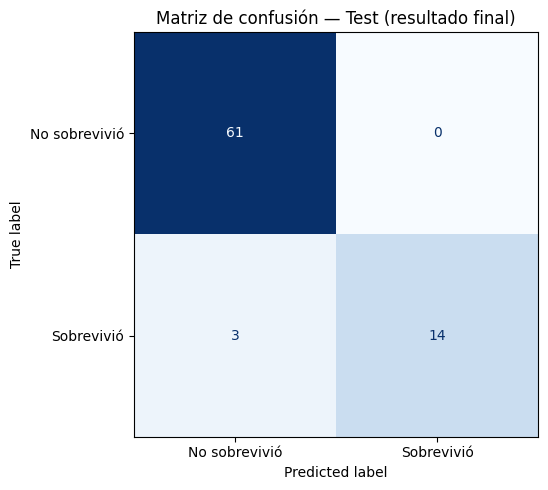

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_test = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['No sobrevivió', 'Sobrevivió'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — Test (resultado final)')
plt.tight_layout()
plt.show()